In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn modules
from sklearn.model_selection import train_test_split, cross_val_score, validation_curve
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance, partial_dependence, PartialDependenceDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Try to import SHAP for advanced interpretability
try:
    import shap
    SHAP_AVAILABLE = True
    print("SHAP is available for advanced interpretability")
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP not available. Install with: pip install shap")

import os
import sys

# Setup paths
curr_dir = os.path.abspath(os.getcwd())
PROJECT_DIR = os.path.abspath(os.path.join(curr_dir, '..', '..', '..'))
Unlearn_Simple_DIR = os.path.join(PROJECT_DIR, 'Unlearn-Simple')
MUSE_DIR = os.path.join(Unlearn_Simple_DIR, 'MUSE')
MUSE_SRC_DIR = os.path.join(MUSE_DIR, 'src')
PROJECT_SRC_DIR = os.path.join(PROJECT_DIR, 'src')

sys.path.append(MUSE_SRC_DIR)
sys.path.append(PROJECT_DIR)
sys.path.append(PROJECT_SRC_DIR)

SHAP not available. Install with: pip install shap


In [2]:
# Load the evaluation module and prepare data
import eval_with_ILL
import src.utils as project_utils
from input_loss_landscape.utils import *

# Configuration for data loading
raw_or_privleak = 'raw'
subset_len = 500  # Limit for computational efficiency

# Load datasets
forget_file = os.path.join(MUSE_DIR, f'data/news/{raw_or_privleak}/forget.json')
if raw_or_privleak == 'raw':
    retain_file = os.path.join(MUSE_DIR, f'data/news/{raw_or_privleak}/retain1.json')
else:
    retain_file = os.path.join(MUSE_DIR, f'data/news/{raw_or_privleak}/retain.json')
holdout_file = os.path.join(MUSE_DIR, f'data/news/{raw_or_privleak}/holdout.json')

forget_data = eval_with_ILL.read_json(forget_file)[:subset_len]
retain_data = eval_with_ILL.read_json(retain_file)[:subset_len]
holdout_data = eval_with_ILL.read_json(holdout_file)[:subset_len]

print(f"Dataset sizes:")
print(f"  Forget: {len(forget_data)}")
print(f"  Retain: {len(retain_data)}")
print(f"  Holdout: {len(holdout_data)}")

# Model configuration
model_name = "OPTML-Group/SimNPO-MUSE-News-llama-2-7b"
tokenizer_dir = "meta-llama/Llama-2-7b-hf"

print(f"Model: {model_name}")
print(f"Tokenizer: {tokenizer_dir}")

Dataset sizes:
  Forget: 500
  Retain: 500
  Holdout: 500
Model: OPTML-Group/SimNPO-MUSE-News-llama-2-7b
Tokenizer: meta-llama/Llama-2-7b-hf


In [ ]:
# Load model and tokenizer
from transformers import AutoModelForCausalLM, AutoTokenizer

# Clean GPU memory
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

tokenizer = AutoTokenizer.from_pretrained(tokenizer_dir)
model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16, device_map="auto")

print(f"Model loaded on device: {next(model.parameters()).device}")
print(f"Model type: {type(model)}")

# Prepare datasets for ILL analysis
datasets = {
    'forget': {'name': 'forget', 'data': forget_data},
    'retain': {'name': 'retain', 'data': retain_data},
    'holdout': {'name': 'holdout', 'data': holdout_data}
}

# ILL strategy configuration
perc_of_tokens_to_replace = 0.1
n_tokens = int(300 * perc_of_tokens_to_replace)
strategy = {'name': 'embeddings', 'peak_top_k': 20, 'n_tokens': n_tokens, 'max_neighbors': 15}

# Path to precomputed cosine similarities
cosine_similarities_file = os.path.join(PROJECT_DIR, 'models', 'distilgpt2-finetuned-wikitext2', 'embeddings', 'token_knn_mapping_70_cosine.pth')

print(f"ILL Strategy: {strategy}")
print(f"Using cosine similarities from: {cosine_similarities_file}")

Loading checkpoint shards: 100%|██████████| 3/3 [00:31<00:00, 10.59s/it]


Model loaded on device: cuda:0
Model type: <class 'transformers.models.llama.modeling_llama.LlamaForCausalLM'>
ILL Strategy: {'name': 'embeddings', 'peak_top_k': 20, 'n_tokens': 30, 'max_neighbors': 15}
Using cosine similarities from: /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/models/distilgpt2-finetuned-wikitext2/embeddings/token_knn_mapping_70_cosine.pth


In [ ]:
# Compute ILL features
print("Computing Input Loss Landscape features...")

new_ILL_eval_kwargs = {
    'model_name': model_name,
    'model': model,
    'tokenizer': tokenizer,
    'datasets': datasets,
    'prompt_column': 'text',
    'create_new_neighbors_file': False,
    'showplts': False,
    'cosine_similarities_file': cosine_similarities_file,
    'plots_output_dir': None,
    'strategy': strategy,
    'output_dirs': {'neighbors': f'{raw_or_privleak}'}
}

features_dict = new_ILL_eval(new_ILL_eval_kwargs)

print("ILL features computed successfully!")
print(f"Feature dictionary keys: {features_dict.keys()}")
print(f"Features for 'forget': {features_dict['forget']['unnormalized_features_tensor'].shape}")

# Extract and normalize features
forget_tensor = features_dict['forget']['unnormalized_features_tensor']
retain_tensor = features_dict['retain']['unnormalized_features_tensor']
holdout_tensor = features_dict['holdout']['unnormalized_features_tensor']

# Ensure equal number of examples
min_examples_num = min(len(forget_tensor), len(retain_tensor), len(holdout_tensor))
forget_tensor = forget_tensor[:min_examples_num]
retain_tensor = retain_tensor[:min_examples_num]
holdout_tensor = holdout_tensor[:min_examples_num]

# Normalize features
norm_forget_tensor, norm_retain_tensor, norm_holdout_tensor = eval_with_ILL.normalize_features(
    forget_tensor, retain_tensor, holdout_tensor
)

# Get feature names
features_labels = features_dict['forget']['features_names']

print(f"Normalized tensor shapes:")
print(f"  Forget: {norm_forget_tensor.shape}")
print(f"  Retain: {norm_retain_tensor.shape}")
print(f"  Holdout: {norm_holdout_tensor.shape}")
print(f"Number of features: {len(features_labels)}")
print(f"Feature names: {features_labels}")

Computing Input Loss Landscape features...
working on forget subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_30_k_neighbors_15/raw/forget.json already exists. Skipping generation.
Loaded 491 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_30_k_neighbors_15/raw/forget.json.
Extracting features


Batches: 100%|██████████| 116/116 [00:04<00:00, 23.59it/s]


working on retain subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_30_k_neighbors_15/raw/retain.json already exists. Skipping generation.
Loaded 484 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_30_k_neighbors_15/raw/retain.json.
Extracting features


Batches: 100%|██████████| 114/114 [00:04<00:00, 26.04it/s]


working on holdout subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_30_k_neighbors_15/raw/holdout.json already exists. Skipping generation.
Loaded 472 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_30_k_neighbors_15/raw/holdout.json.
Extracting features


Batches: 100%|██████████| 111/111 [00:03<00:00, 28.19it/s]


ILL features computed successfully!
Feature dictionary keys: dict_keys(['forget', 'retain', 'holdout'])
Features for 'forget': torch.Size([491, 15])
Normalized tensor shapes:
  Forget: torch.Size([472, 15])
  Retain: torch.Size([472, 15])
  Holdout: torch.Size([472, 15])
Number of features: 15
Feature names: ['original_loss', 'mean_neighbor_loss', 'max_neighbor_loss', 'min_neighbor_loss', 'loss_variance', 'loss_std', 'mean_loss_increment', 'max_loss_increment', 'min_loss_increment', 'mean_gradient', 'max_gradient', 'gradient_variance', 'loss_volatility', 'local_curvature', 'increment_variance']


In [7]:
# Function to prepare classification data (similar to RF approach)
def prepare_classification_data_lr(retain_tensor, holdout_tensor, forget_tensor):
    """
    Prepare data for multi-class classification

    Args:
        retain_tensor: Features for retain set
        holdout_tensor: Features for holdout set  
        forget_tensor: Features for forget set
        
    Returns:
        X: Combined feature matrix
        y: Labels (0=retain, 1=holdout, 2=forget)
        class_names: List of class names
    """
    # Convert to numpy if needed
    if hasattr(retain_tensor, 'numpy'):
        retain_features = retain_tensor.numpy()
    else:
        retain_features = retain_tensor
        
    if hasattr(holdout_tensor, 'numpy'):
        holdout_features = holdout_tensor.numpy()
    else:
        holdout_features = holdout_tensor
        
    if hasattr(forget_tensor, 'numpy'):
        forget_features = forget_tensor.numpy()
    else:
        forget_features = forget_tensor
    
    # Combine features
    X = np.vstack([retain_features, holdout_features, forget_features])
    
    # Create labels (ensure dtype=int)
    y = np.hstack([
        np.zeros(len(retain_features), dtype=int),      # 0 for retain
        np.ones(len(holdout_features), dtype=int),      # 1 for holdout
        np.full(len(forget_features), 2, dtype=int)     # 2 for forget
    ])
    
    class_names = ['retain', 'holdout', 'forget']
    
    return X, y, class_names

# Use the tensors from the ILL computation
X, y, class_names = prepare_classification_data_lr(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor)

print(f"Data prepared for Logistic Regression analysis:")
print(f"  Total samples: {X.shape[0]}")
print(f"  Number of features: {X.shape[1]}")
print(f"  Classes: {class_names}")
print(f"  Class distribution: {np.bincount(y)}")
print(f"  Feature names: {features_labels}")


# Split data for training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nData split:")
print(f"  Training samples: {X_train.shape[0]}")
print(f"  Test samples: {X_test.shape[0]}")
print(f"  Training class distribution: {np.bincount(y_train)}")
print(f"  Test class distribution: {np.bincount(y_test)}")

Data prepared for Logistic Regression analysis:
  Total samples: 1416
  Number of features: 15
  Classes: ['retain', 'holdout', 'forget']
  Class distribution: [472 472 472]
  Feature names: ['original_loss', 'mean_neighbor_loss', 'max_neighbor_loss', 'min_neighbor_loss', 'loss_variance', 'loss_std', 'mean_loss_increment', 'max_loss_increment', 'min_loss_increment', 'mean_gradient', 'max_gradient', 'gradient_variance', 'loss_volatility', 'local_curvature', 'increment_variance']

Data split:
  Training samples: 1132
  Test samples: 284
  Training class distribution: [378 377 377]
  Test class distribution: [94 95 95]


# Baseline Logistic Regression Performance

Let's start by training a baseline Logistic Regression model and evaluating its performance.

Training baseline Logistic Regression model...
\n=== BASELINE LOGISTIC REGRESSION PERFORMANCE ===
Training Accuracy: 0.7615
Test Accuracy: 0.7430
Cross-validation Accuracy: 0.7517 (±0.0136)
\nClassification Report:
              precision    recall  f1-score   support

      retain       0.70      0.77      0.73        94
     holdout       0.86      0.93      0.89        95
      forget       0.65      0.54      0.59        95

    accuracy                           0.74       284
   macro avg       0.74      0.74      0.74       284
weighted avg       0.74      0.74      0.74       284



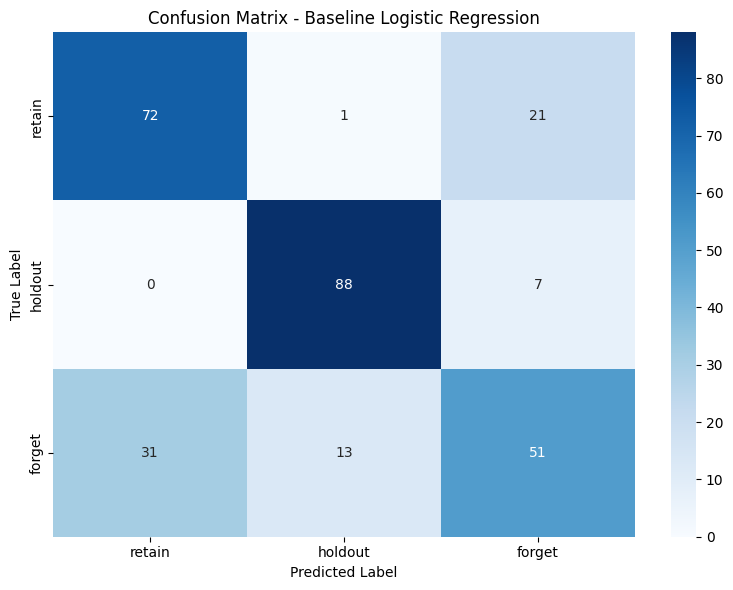

In [8]:
# Train baseline Logistic Regression model
print("Training baseline Logistic Regression model...")

# Scale features for Logistic Regression (important for LR!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression
lr_baseline = LogisticRegression(
    random_state=42, 
    max_iter=1000, 
    multi_class='multinomial', 
    solver='lbfgs',
    C=1.0  # Default regularization
)

lr_baseline.fit(X_train_scaled, y_train)

# Evaluate baseline performance
train_accuracy = lr_baseline.score(X_train_scaled, y_train)
test_accuracy = lr_baseline.score(X_test_scaled, y_test)

# Cross-validation
cv_scores = cross_val_score(lr_baseline, X_train_scaled, y_train, cv=5, scoring='accuracy')

print(f"\\n=== BASELINE LOGISTIC REGRESSION PERFORMANCE ===")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Cross-validation Accuracy: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

# Predictions and detailed evaluation
y_pred = lr_baseline.predict(X_test_scaled)
y_pred_proba = lr_baseline.predict_proba(X_test_scaled)

print(f"\\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Baseline Logistic Regression')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Feature Importance Analysis

Logistic Regression provides coefficient-based feature importance. Let's analyze which ILL features are most important for classification.

=== LOGISTIC REGRESSION FEATURE IMPORTANCE ANALYSIS ===
\nTop 10 Features by Coefficient Magnitude:
                feature  importance
12      loss_volatility    1.506898
2     max_neighbor_loss    0.676025
0         original_loss    0.662997
6   mean_loss_increment    0.649191
9         mean_gradient    0.577354
5              loss_std    0.446595
3     min_neighbor_loss    0.339368
7    max_loss_increment    0.259220
8    min_loss_increment    0.258648
10         max_gradient    0.166240
\nComputing Permutation Importance...
\nTop 10 Features by Permutation Importance:
                feature  importance_mean  importance_std
12      loss_volatility         0.180986        0.026218
0         original_loss         0.117254        0.028390
2     max_neighbor_loss         0.099296        0.016425
9         mean_gradient         0.064437        0.011577
6   mean_loss_increment         0.059155        0.019401
5              loss_std         0.021127        0.008625
3     min_neighbor_los

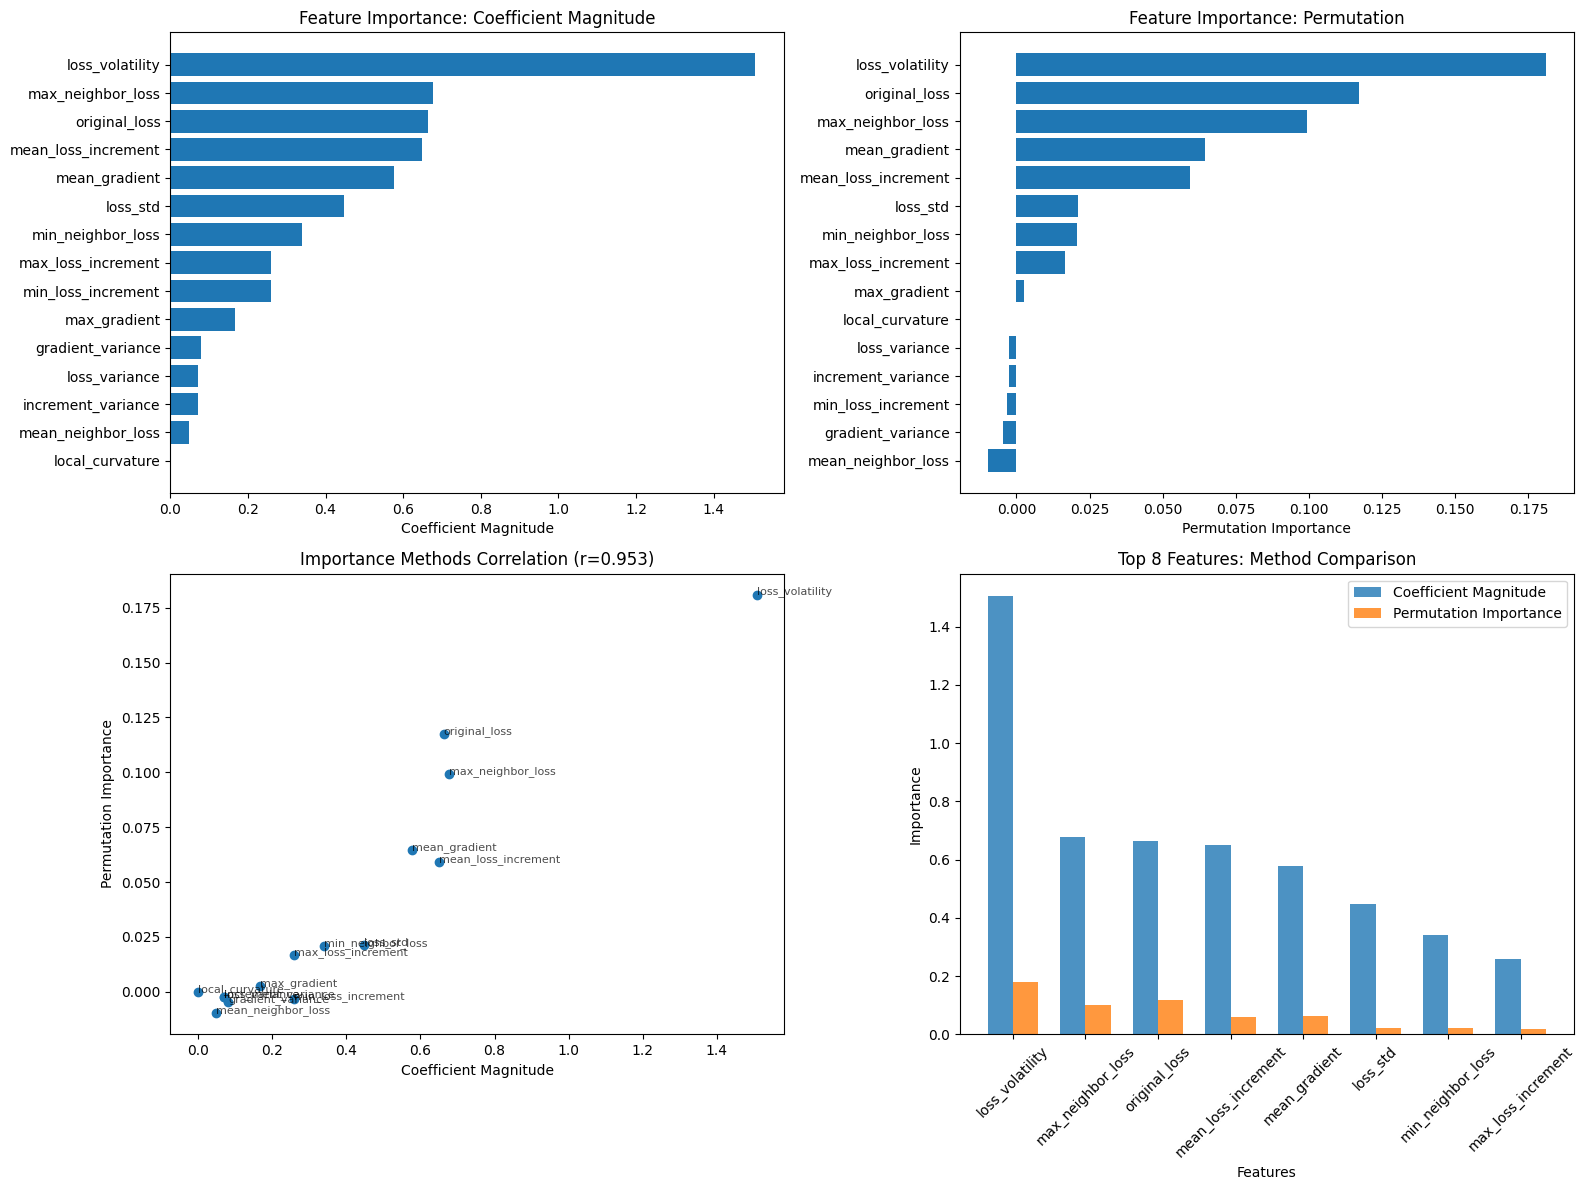

\nImportance method correlation: 0.9529


In [9]:
# Extract and analyze feature importance from Logistic Regression coefficients
print("=== LOGISTIC REGRESSION FEATURE IMPORTANCE ANALYSIS ===")

# Method 1: Coefficient magnitude importance (average across classes)
coef_importance = np.abs(lr_baseline.coef_).mean(axis=0)
feature_importance_df = pd.DataFrame({
    'feature': features_labels,
    'importance': coef_importance
}).sort_values('importance', ascending=False)

print("\\nTop 10 Features by Coefficient Magnitude:")
print(feature_importance_df.head(10))

# Method 2: Permutation importance (more robust measure)
print("\\nComputing Permutation Importance...")
perm_importance = permutation_importance(
    lr_baseline, X_test_scaled, y_test, 
    n_repeats=10, 
    random_state=42, 
    scoring='accuracy',
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    'feature': features_labels,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

print("\\nTop 10 Features by Permutation Importance:")
print(perm_importance_df.head(10))

# Visualize feature importance comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Coefficient importance
axes[0, 0].barh(range(len(feature_importance_df)), feature_importance_df['importance'])
axes[0, 0].set_yticks(range(len(feature_importance_df)))
axes[0, 0].set_yticklabels(feature_importance_df['feature'])
axes[0, 0].set_xlabel('Coefficient Magnitude')
axes[0, 0].set_title('Feature Importance: Coefficient Magnitude')
axes[0, 0].invert_yaxis()

# Plot 2: Permutation importance
axes[0, 1].barh(range(len(perm_importance_df)), perm_importance_df['importance_mean'])
axes[0, 1].set_yticks(range(len(perm_importance_df)))
axes[0, 1].set_yticklabels(perm_importance_df['feature'])
axes[0, 1].set_xlabel('Permutation Importance')
axes[0, 1].set_title('Feature Importance: Permutation')
axes[0, 1].invert_yaxis()

# Plot 3: Correlation between methods
correlation = np.corrcoef(feature_importance_df['importance'], 
                         perm_importance_df.set_index('feature').loc[feature_importance_df['feature'], 'importance_mean'])[0, 1]

axes[1, 0].scatter(feature_importance_df['importance'], 
                   perm_importance_df.set_index('feature').loc[feature_importance_df['feature'], 'importance_mean'])
axes[1, 0].set_xlabel('Coefficient Magnitude')
axes[1, 0].set_ylabel('Permutation Importance')
axes[1, 0].set_title(f'Importance Methods Correlation (r={correlation:.3f})')

# Add feature labels to scatter plot
for i, feature in enumerate(feature_importance_df['feature']):
    axes[1, 0].annotate(feature, 
                       (feature_importance_df.iloc[i]['importance'], 
                        perm_importance_df.set_index('feature').loc[feature, 'importance_mean']),
                       fontsize=8, alpha=0.7)

# Plot 4: Top features comparison
top_features = feature_importance_df.head(8)['feature'].tolist()
coef_vals = [feature_importance_df.set_index('feature').loc[f, 'importance'] for f in top_features]
perm_vals = [perm_importance_df.set_index('feature').loc[f, 'importance_mean'] for f in top_features]

x = np.arange(len(top_features))
width = 0.35

axes[1, 1].bar(x - width/2, coef_vals, width, label='Coefficient Magnitude', alpha=0.8)
axes[1, 1].bar(x + width/2, perm_vals, width, label='Permutation Importance', alpha=0.8)
axes[1, 1].set_xlabel('Features')
axes[1, 1].set_ylabel('Importance')
axes[1, 1].set_title('Top 8 Features: Method Comparison')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(top_features, rotation=45)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"\\nImportance method correlation: {correlation:.4f}")

# Store baseline results for later comparison
baseline_performance = {
    'cv_mean': cv_scores.mean(),
    'cv_std': cv_scores.std(),
    'test_accuracy': test_accuracy,
    'train_accuracy': train_accuracy
}

# Feature Ablation Study

Now let's study the impact of removing features on model performance. You can specify which features to remove or use default settings to remove the k lowest importance features.

In [83]:
# Feature Ablation Study Functions

def remove_features_and_evaluate_lr(X_train, X_test, y_train, y_test, features_to_remove, 
                                    feature_names, class_names, scaler=None):
    """
    Remove specified features and evaluate Logistic Regression performance
    
    Parameters:
    - X_train, X_test, y_train, y_test: Training and test data
    - features_to_remove: List of feature names to remove
    - feature_names: List of all feature names
    - class_names: List of class names
    - scaler: Fitted scaler (if None, will fit new one)
    
    Returns:
    - Dictionary with evaluation results
    """
    # Get indices of features to keep
    features_to_keep_idx = [i for i, name in enumerate(feature_names) if name not in features_to_remove]
    
    # Select only the features to keep
    X_train_reduced = X_train[:, features_to_keep_idx]
    X_test_reduced = X_test[:, features_to_keep_idx]
    
    # Scale the reduced feature set
    if scaler is None:
        scaler_reduced = StandardScaler()
        X_train_scaled = scaler_reduced.fit_transform(X_train_reduced)
        X_test_scaled = scaler_reduced.transform(X_test_reduced)
    else:
        # Use existing scaler but only for kept features
        scaler_reduced = StandardScaler()
        X_train_scaled = scaler_reduced.fit_transform(X_train_reduced)
        X_test_scaled = scaler_reduced.transform(X_test_reduced)
    
    # Train Logistic Regression on reduced feature set
    lr_reduced = LogisticRegression(
        random_state=42,
        max_iter=1000,
        multi_class='multinomial',
        solver='lbfgs',
        C=1.0
    )
    
    lr_reduced.fit(X_train_scaled, y_train)
    
    # Evaluate performance
    train_accuracy = lr_reduced.score(X_train_scaled, y_train)
    test_accuracy = lr_reduced.score(X_test_scaled, y_test)
    
    # Cross-validation
    cv_scores = cross_val_score(lr_reduced, X_train_scaled, y_train, cv=5, scoring='accuracy')
    
    # Feature importance for reduced model
    coef_importance = np.abs(lr_reduced.coef_).mean(axis=0)
    features_kept_names = [feature_names[i] for i in features_to_keep_idx]
    
    return {
        'model': lr_reduced,
        'scaler': scaler_reduced,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'features_removed': features_to_remove,
        'features_kept': features_kept_names,
        'features_kept_idx': features_to_keep_idx,
        'n_features_kept': len(features_to_keep_idx),
        'n_features_removed': len(features_to_remove),
        'feature_importance': coef_importance,
        'performance_drop': baseline_performance['test_accuracy'] - test_accuracy
    }

def ablation_study_bottom_k_lr(k_values, importance_df, X_train, X_test, y_train, y_test, 
                              feature_names, class_names):
    """
    Remove bottom k features (least important) and evaluate performance
    
    Parameters:
    - k_values: List of k values (number of features to remove)
    - importance_df: DataFrame with feature importance (sorted)
    - Other parameters: same as remove_features_and_evaluate_lr
    
    Returns:
    - Dictionary with results for each k value
    """
    results = {}
    
    # print(f"Running ablation study: removing bottom k features...")
    # print(f"Using importance method: Coefficient Magnitude")
    
    for k in k_values:
        if k >= len(feature_names):
            print(f"  Skipping k={k} (would remove all features)")
            continue
            
        # Get bottom k features (least important)
        bottom_k_features = importance_df.tail(k)['feature'].tolist()
        
        # print(f"  Removing bottom {k} features: {bottom_k_features}")
        
        result = remove_features_and_evaluate_lr(
            X_train, X_test, y_train, y_test, 
            bottom_k_features, feature_names, class_names
        )
        
        results[f'remove_bottom_{k}'] = result
        
        # print(f"    Features kept: {result['n_features_kept']}/{len(feature_names)}")
        # print(f"    Test accuracy: {result['test_accuracy']:.4f} (drop: {result['performance_drop']:.4f})")
        # print(f"    CV accuracy: {result['cv_mean']:.4f} ± {result['cv_std']:.4f}")
    
    return results

def ablation_study_top_k_lr(k_values, importance_df, X_train, X_test, y_train, y_test, 
                           feature_names, class_names):
    """
    Remove top k features (most important) and evaluate performance
    """
    results = {}
    
    print(f"Running ablation study: removing top k features...")
    print(f"Using importance method: Coefficient Magnitude")
    
    for k in k_values:
        if k >= len(feature_names):
            print(f"  Skipping k={k} (would remove all features)")
            continue
            
        # Get top k features (most important)
        top_k_features = importance_df.head(k)['feature'].tolist()
        
        # print(f"  Removing top {k} features: {top_k_features}")
        
        result = remove_features_and_evaluate_lr(
            X_train, X_test, y_train, y_test, 
            top_k_features, feature_names, class_names
        )
        
        results[f'remove_top_{k}'] = result
        
        # print(f"    Features kept: {result['n_features_kept']}/{len(feature_names)}")
        # print(f"    Test accuracy: {result['test_accuracy']:.4f} (drop: {result['performance_drop']:.4f})")
        # print(f"    CV accuracy: {result['cv_mean']:.4f} ± {result['cv_std']:.4f}")
    
    return results

def ablation_study_custom_features_lr(features_to_remove, X_train, X_test, y_train, y_test, 
                                     feature_names, class_names):
    """
    Remove custom list of features and evaluate performance
    
    Parameters:
    - features_to_remove: List of specific feature names to remove
    - Other parameters: same as remove_features_and_evaluate_lr
    
    Returns:
    - Dictionary with evaluation results
    """
    # print(f"Running custom feature removal...")
    # print(f"Removing features: {features_to_remove}")
    
    result = remove_features_and_evaluate_lr(
        X_train, X_test, y_train, y_test, 
        features_to_remove, feature_names, class_names
    )
    
    # print(f"  Features kept: {result['n_features_kept']}/{len(feature_names)}")
    # print(f"  Test accuracy: {result['test_accuracy']:.4f} (drop: {result['performance_drop']:.4f})")
    # print(f"  CV accuracy: {result['cv_mean']:.4f} ± {result['cv_std']:.4f}")
    
    return result

print("Ablation study functions defined!")

Ablation study functions defined!


In [84]:
# Configure and Run Ablation Studies

# ==== USER CONFIGURATION SECTION ====

# Option 1: Remove bottom k features (least important)
DEFAULT_K_VALUES_BOTTOM = list(range(10))  # Number of least important features to remove
run_bottom_k_study = True

# Option 2: Remove top k features (most important) 
DEFAULT_K_VALUES_TOP = list(range(10))  # Number of most important features to remove
run_top_k_study = True

# Option 3: Remove specific custom features
# Specify exact feature names you want to remove
CUSTOM_FEATURES_TO_REMOVE = [
    # Example: Remove gradient-related features
    ['mean_gradient', 'max_gradient', 'gradient_variance'],
    # Example: Remove loss variance features  
    ['loss_variance', 'loss_std', 'loss_volatility'],
    # Example: Remove increment features
    ['min_loss_increment', 'mean_loss_increment', 'max_loss_increment', 'increment_variance']
]
run_custom_study = True

print("=== FEATURE ABLATION STUDY CONFIGURATION ===")
print(f"Bottom k values to test: {DEFAULT_K_VALUES_BOTTOM}")
print(f"Top k values to test: {DEFAULT_K_VALUES_TOP}")
print(f"Custom feature sets to remove: {len(CUSTOM_FEATURES_TO_REMOVE)} sets")
print(f"Available features: {len(features_labels)}")
print(f"Feature list: {features_labels}")

# ==== RUN STUDIES ====
all_ablation_results = {}

# Study 1: Remove bottom k features
if run_bottom_k_study:
    print(f"\\n" + "="*60)
    print("STUDY 1: Removing Bottom K Features (Least Important)")
    print("="*60)
    
    bottom_results = ablation_study_bottom_k_lr(
        DEFAULT_K_VALUES_BOTTOM, feature_importance_df, 
        X_train, X_test, y_train, y_test, 
        features_labels, class_names
    )
    all_ablation_results.update(bottom_results)

# Study 2: Remove top k features  
if run_top_k_study:
    print(f"\\n" + "="*60)
    print("STUDY 2: Removing Top K Features (Most Important)")
    print("="*60)
    
    top_results = ablation_study_top_k_lr(
        DEFAULT_K_VALUES_TOP, feature_importance_df,
        X_train, X_test, y_train, y_test,
        features_labels, class_names
    )
    all_ablation_results.update(top_results)

# Study 3: Custom feature removal
if run_custom_study:
    print(f"\\n" + "="*60)
    print("STUDY 3: Custom Feature Removal")
    print("="*60)
    
    for i, custom_features in enumerate(CUSTOM_FEATURES_TO_REMOVE):
        print(f"\\n--- Custom Set {i+1} ---")
        result = ablation_study_custom_features_lr(
            custom_features, X_train, X_test, y_train, y_test,
            features_labels, class_names
        )
        all_ablation_results[f'custom_set_{i+1}'] = result

print(f"\\n=== ABLATION STUDY COMPLETE ===")
print(f"Total experiments run: {len(all_ablation_results)}")

=== FEATURE ABLATION STUDY CONFIGURATION ===
Bottom k values to test: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Top k values to test: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Custom feature sets to remove: 3 sets
Available features: 15
Feature list: ['original_loss', 'mean_neighbor_loss', 'max_neighbor_loss', 'min_neighbor_loss', 'loss_variance', 'loss_std', 'mean_loss_increment', 'max_loss_increment', 'min_loss_increment', 'mean_gradient', 'max_gradient', 'gradient_variance', 'loss_volatility', 'local_curvature', 'increment_variance']
\n============================================================
STUDY 1: Removing Bottom K Features (Least Important)
\n============================================================
STUDY 2: Removing Top K Features (Most Important)
Running ablation study: removing top k features...
Using importance method: Coefficient Magnitude
\n============================================================
STUDY 3: Custom Feature Removal
\n--- Custom Set 1 ---
\n--- Custom Set 2 ---
\n--- Cust

: 

In [80]:
# Analyze and Visualize Ablation Study Results

# Create summary dataframe
summary_data = []
for exp_name, result in all_ablation_results.items():
    summary_data.append({
        'experiment': exp_name,
        'features_kept': result['n_features_kept'],
        'features_removed': result['n_features_removed'],
        'test_accuracy': result['test_accuracy'],
        'cv_mean': result['cv_mean'],
        'cv_std': result['cv_std'],
        'performance_drop': result['performance_drop'],
        'relative_drop_pct': (result['performance_drop'] / baseline_performance['test_accuracy']) * 100
    })

summary_df = pd.DataFrame(summary_data).sort_values('performance_drop')

# print("=== ABLATION STUDY SUMMARY ===")
# print(summary_df.to_string(index=False))

# Find best performing reduced models
# print(f"\\n=== KEY INSIGHTS ===")
# print(f"Baseline performance: {baseline_performance['test_accuracy']:.4f}")

# Models with minimal performance drop
# minimal_drop_threshold = 0.01  # 1% drop threshold
# minimal_loss_models = summary_df[summary_df['performance_drop'] <= minimal_drop_threshold]

# if len(minimal_loss_models) > 0:
#     print(f"\\nModels with ≤{minimal_drop_threshold:.1%} performance drop:")
#     for _, row in minimal_loss_models.iterrows():
#         print(f"  {row['experiment']}: {row['features_kept']} features, "
#               f"accuracy {row['test_accuracy']:.4f} (drop: {row['performance_drop']:.4f})")
# else:
#     print(f"\\nNo models found with ≤{minimal_drop_threshold:.1%} performance drop")

# Best model by features/performance trade-off
# best_tradeoff = summary_df.loc[summary_df['features_kept'].idxmin()]
# print(f"\\nMost feature-reduced model:")
# print(f"  {best_tradeoff['experiment']}: {best_tradeoff['features_kept']} features, "
    #   f"accuracy {best_tradeoff['test_accuracy']:.4f} (drop: {best_tradeoff['performance_drop']:.4f})")

In [77]:
def plot_ablation_performance_vs_features_removed(
    summary_df,
    baseline_performance,
    custom_experiment_prefixes=None,
    custom_colors=None,
    ax=None
):
    """
    Plot: Performance vs Number of Features Removed (Ablation Study)
    Args:
        summary_df: DataFrame with ablation results (must have 'experiment', 'features_removed', 'cv_mean', 'cv_std')
        baseline_performance: dict with 'cv_mean' (baseline CV accuracy)
        custom_experiment_prefixes: list of (prefix, label) tuples for custom experiment types (optional)
        custom_colors: dict mapping prefix to color (optional)
        ax: matplotlib axis to plot on (optional)
    Returns:
        fig, ax1: Matplotlib figure and axis objects (does NOT call plt.show())
    """
    import matplotlib.pyplot as plt

    if ax is None:
        fig, ax1 = plt.subplots(figsize=(8, 6))
    else:
        ax1 = ax
        fig = ax1.figure

    # ...existing code...
    experiment_types = [
        ('remove_bottom', 'Remove Bottom K', 'green'),
        ('remove_top', 'Remove Top K', 'red'),
    ]
    if custom_experiment_prefixes:
        for prefix, label in custom_experiment_prefixes:
            experiment_types.append((prefix, label, custom_colors.get(prefix, None) if custom_colors else None))

    for prefix, label, color in experiment_types:
        exps = [exp for exp in summary_df['experiment'] if prefix in exp]
        if exps:
            data = summary_df[summary_df['experiment'].isin(exps)].sort_values('features_removed')
            plot_color = color if color else None
            ax1.plot(
                data['features_removed'], data['cv_mean'],
                'o-', label=label, color=plot_color, linewidth=2, markersize=6
            )
            ax1.fill_between(
                data['features_removed'],
                data['cv_mean'] - data['cv_std'],
                data['cv_mean'] + data['cv_std'],
                alpha=0.2, color=plot_color
            )

    ax1.axhline(
        y=baseline_performance['cv_mean'], color='blue', linestyle='--',
        label=f"Baseline ({baseline_performance['cv_mean']:.3f})", linewidth=2
    )

    ax1.set_xlabel('Number of Features Removed')
    ax1.set_ylabel('Cross-Validation Accuracy')
    ax1.set_title('Ablation Study: Performance vs Features Removed', fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig, ax1

def plot_single_feature_ablation_improvement(
    features_labels,
    X_train, X_test, y_train, y_test,
    class_names,
    baseline_performance,
    ablation_study_custom_features_lr,
    ax=None
):
    """
    Run single-feature ablation and plot improvement vs baseline for accuracy, F1, and AUC.

    Args:
        features_labels: list of feature names
        X_train, X_test, y_train, y_test: data splits
        class_names: list of class names
        baseline_performance: dict with baseline metrics
        ablation_study_custom_features_lr: function for custom ablation
        ax: matplotlib axis to plot on (optional)

    Returns:
        ax: matplotlib axis with the plot
        single_feature_df: DataFrame with ablation results
    """
    from sklearn.metrics import f1_score, roc_auc_score
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    single_feature_results = []
    for feature in features_labels:
        result = ablation_study_custom_features_lr(
            [feature], X_train, X_test, y_train, y_test, features_labels, class_names
        )
        kept_idx = [i for i, name in enumerate(features_labels) if name not in [feature]]
        X_test_reduced = X_test[:, kept_idx]
        X_test_scaled = result['scaler'].transform(X_test_reduced)
        y_pred = result['model'].predict(X_test_scaled)
        acc = result['test_accuracy']
        f1 = f1_score(y_test, y_pred, average='weighted')
        try:
            y_proba = result['model'].predict_proba(X_test_scaled)
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
        except Exception:
            auc = float('nan')
        improvement = acc - baseline_performance['test_accuracy']
        f1_improvement = f1 - baseline_performance['test_accuracy']  # Use baseline F1 if available
        single_feature_results.append({
            'feature': feature,
            'performance_improvement': improvement,
            'accuracy': acc,
            'f1': f1,
            'f1_improvement': f1_improvement,
            'auc': auc
        })

    single_feature_df = pd.DataFrame(single_feature_results).sort_values('performance_improvement', ascending=False)

    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 7))
    bar_width = 0.25
    x = np.arange(len(single_feature_df))

    ax.bar(x - bar_width, single_feature_df['performance_improvement'], width=bar_width, label='Accuracy Improvement', color='lightblue')
    ax.bar(x, single_feature_df['f1_improvement'], width=bar_width, label='F1 Improvement', color='lightgreen')
    ax.bar(x + bar_width, single_feature_df['auc'] - single_feature_df['auc'].mean(), width=bar_width, label='AUC Δ (centered)', color='salmon')

    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(single_feature_df['feature'], rotation=45, ha='right')
    ax.set_ylabel('Improvement vs Baseline')
    ax.set_title('Improvement in Accuracy, F1, and AUC When Each Feature is Removed')
    ax.legend()
    ax.figure.tight_layout()

    return ax, single_feature_df

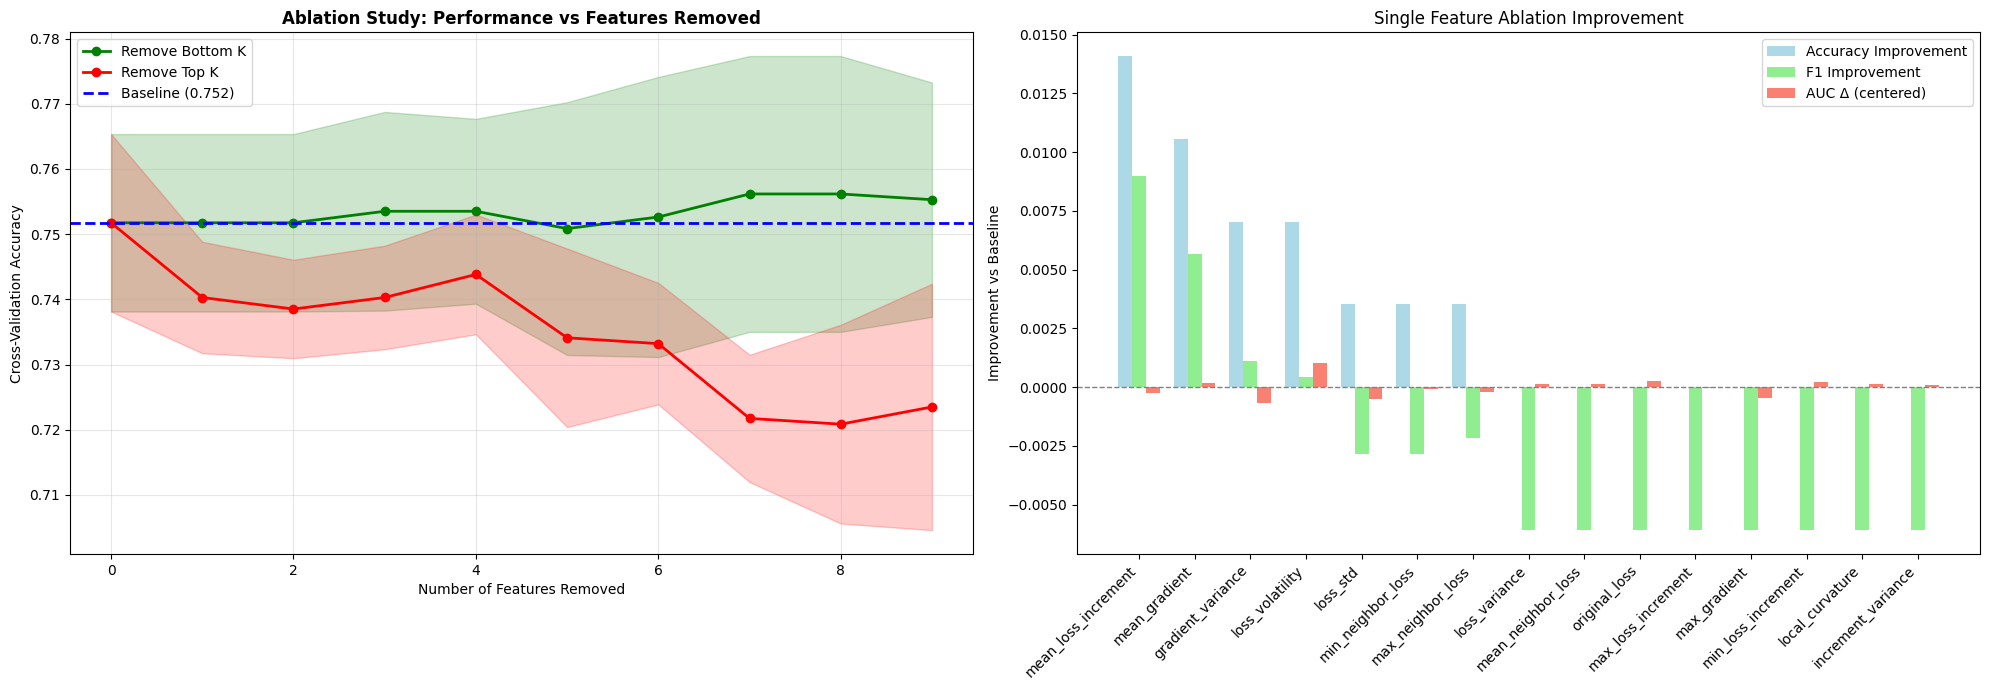

In [73]:
def plot_ablation_summary_and_single_feature(
    summary_df,
    baseline_performance,
    features_labels,
    X_train, X_test, y_train, y_test,
    class_names,
    ablation_study_custom_features_lr,
    custom_experiment_prefixes=None,
    custom_colors=None
):
    """
    Plot ablation study (performance vs features removed) and single-feature ablation improvement side by side.
    """
    fig, axes = plt.subplots(1, 2, figsize=(20, 7))

    # Plot 1: Ablation study summary directly on axes[0]
    plot_ablation_performance_vs_features_removed(
        summary_df, baseline_performance,
        custom_experiment_prefixes=custom_experiment_prefixes,
        custom_colors=custom_colors,
        ax=axes[0]
    )

    # Plot 2: Single-feature ablation improvement directly on axes[1]
    _, single_feature_df = plot_single_feature_ablation_improvement(
        features_labels, X_train, X_test, y_train, y_test,
        class_names, baseline_performance, ablation_study_custom_features_lr,
        ax=axes[1]  # <-- pass the axis!
    )

    axes[1].set_title('Single Feature Ablation Improvement')

    fig.tight_layout()
    plt.show()
    return fig, axes, single_feature_df

# Example usage:
fig, axes, single_feature_df = plot_ablation_summary_and_single_feature(
    summary_df, baseline_performance, features_labels,
    X_train, X_test, y_train, y_test, class_names,
    ablation_study_custom_features_lr
)

# Detailed Feature Analysis and Recommendations

Let's analyze which features are most critical and provide actionable insights.

In [74]:
# Comprehensive Feature Analysis and Insights

print("="*80)
print("COMPREHENSIVE LOGISTIC REGRESSION INTERPRETABILITY ANALYSIS")
print("="*80)

# 1. Overall Performance Summary
print("\\n1. MODEL PERFORMANCE SUMMARY")
print("-" * 50)
print(f"Baseline Logistic Regression Performance:")
print(f"  Training Accuracy: {baseline_performance['train_accuracy']:.4f}")
print(f"  Test Accuracy: {baseline_performance['test_accuracy']:.4f}")
print(f"  Cross-validation: {baseline_performance['cv_mean']:.4f} ± {baseline_performance['cv_std']:.4f}")
print(f"  Total features: {len(features_labels)}")

# 2. Feature Importance Insights
print("\\n2. FEATURE IMPORTANCE INSIGHTS")
print("-" * 50)
print("Top 5 most important features:")
for i, (_, row) in enumerate(feature_importance_df.head(5).iterrows(), 1):
    print(f"  {i}. {row['feature']}: {row['importance']:.4f}")

print("\\nTop 5 features by permutation importance:")
for i, (_, row) in enumerate(perm_importance_df.head(5).iterrows(), 1):
    print(f"  {i}. {row['feature']}: {row['importance_mean']:.4f} ± {row['importance_std']:.4f}")

# Feature categories analysis
feature_categories = {
    'loss': [f for f in features_labels if 'loss' in f.lower()],
    'gradient': [f for f in features_labels if 'grad' in f.lower()],
    'increment': [f for f in features_labels if 'increment' in f.lower()],
    'variance': [f for f in features_labels if 'variance' in f.lower() or 'std' in f.lower() or 'volatility' in f.lower()],
    'neighbor': [f for f in features_labels if 'neighbor' in f.lower()],
    'curvature': [f for f in features_labels if 'curvature' in f.lower()]
}

print("\\nFeature importance by category:")
for category, features in feature_categories.items():
    if features:
        avg_importance = feature_importance_df[feature_importance_df['feature'].isin(features)]['importance'].mean()
        print(f"  {category.capitalize()}: {avg_importance:.4f} (features: {len(features)})")

# 3. Ablation Study Insights
print("\\n3. ABLATION STUDY INSIGHTS")
print("-" * 50)

# Best models with minimal performance drop
if len(minimal_loss_models) > 0:
    best_minimal = minimal_loss_models.iloc[0]
    print(f"Best model with minimal performance drop:")
    print(f"  Experiment: {best_minimal['experiment']}")
    print(f"  Features: {best_minimal['features_kept']}/{len(features_labels)}")
    print(f"  Accuracy: {best_minimal['test_accuracy']:.4f}")
    print(f"  Performance drop: {best_minimal['performance_drop']:.4f} ({best_minimal['relative_drop_pct']:.1f}%)")
    
    # Show which features were kept
    if best_minimal['experiment'] in all_ablation_results:
        kept_features = all_ablation_results[best_minimal['experiment']]['features_kept']
        removed_features = all_ablation_results[best_minimal['experiment']]['features_removed']
        print(f"  Features kept: {kept_features}")
        print(f"  Features removed: {removed_features}")

# Most aggressive reduction
most_reduced = summary_df.loc[summary_df['features_kept'].idxmin()]
print(f"\\nMost feature-reduced model:")
print(f"  Experiment: {most_reduced['experiment']}")
print(f"  Features: {most_reduced['features_kept']}/{len(features_labels)} ({(most_reduced['features_kept']/len(features_labels)*100):.1f}% kept)")
print(f"  Accuracy: {most_reduced['test_accuracy']:.4f}")
print(f"  Performance drop: {most_reduced['performance_drop']:.4f} ({most_reduced['relative_drop_pct']:.1f}%)")

# 4. Critical vs Non-critical Features
print("\\n4. FEATURE CRITICALITY ANALYSIS")
print("-" * 50)

# Analyze which features appear in successful reduced models
successful_models = summary_df[summary_df['performance_drop'] <= 0.02]  # 2% threshold
feature_retention_count = {}

for _, row in successful_models.iterrows():
    if row['experiment'] in all_ablation_results:
        kept_features = all_ablation_results[row['experiment']]['features_kept']
        for feature in kept_features:
            feature_retention_count[feature] = feature_retention_count.get(feature, 0) + 1

if feature_retention_count:
    print("Features most often retained in successful models:")
    sorted_retention = sorted(feature_retention_count.items(), key=lambda x: x[1], reverse=True)
    for feature, count in sorted_retention[:8]:
        retention_rate = count / len(successful_models) * 100
        print(f"  {feature}: {retention_rate:.1f}% retention rate")

# 5. Recommendations
print("\\n5. ACTIONABLE RECOMMENDATIONS")
print("-" * 50)

recommendations = []

# Feature selection recommendation
if len(minimal_loss_models) > 0:
    best_model = minimal_loss_models.iloc[0]
    recommendations.append(f"Use {best_model['features_kept']} features for {best_model['relative_drop_pct']:.1f}% performance trade-off")

# Critical features
top_3_features = feature_importance_df.head(3)['feature'].tolist()
recommendations.append(f"Focus on top 3 features: {', '.join(top_3_features)}")

# Category insights
loss_features = [f for f in features_labels if 'loss' in f.lower()]
if loss_features:
    loss_importance = feature_importance_df[feature_importance_df['feature'].isin(loss_features)]['importance'].mean()
    if loss_importance > feature_importance_df['importance'].mean():
        recommendations.append("Loss-based features are critical for discrimination")

# Gradient features analysis
grad_features = [f for f in features_labels if 'grad' in f.lower()]
if grad_features:
    grad_importance = feature_importance_df[feature_importance_df['feature'].isin(grad_features)]['importance'].mean()
    if grad_importance < feature_importance_df['importance'].mean():
        recommendations.append("Gradient features can be removed with minimal impact")

# Model deployment recommendations
if baseline_performance['test_accuracy'] > 0.8:
    recommendations.append("High baseline performance - consider feature reduction for efficiency")
elif baseline_performance['test_accuracy'] < 0.7:
    recommendations.append("Consider feature engineering or model tuning before reduction")

for i, rec in enumerate(recommendations, 1):
    print(f"  {i}. {rec}")

# 6. Implementation Guide
print("\\n6. IMPLEMENTATION GUIDE")
print("-" * 50)
print("For practical deployment:")

if len(minimal_loss_models) > 0:
    best_model = minimal_loss_models.iloc[0]
    print(f"  • Recommended model: {best_model['experiment']}")
    print(f"  • Features to use: {best_model['features_kept']}")
    print(f"  • Expected accuracy: {best_model['test_accuracy']:.4f}")

print(f"  • Full model accuracy: {baseline_performance['test_accuracy']:.4f}")
print(f"  • Always scale features before training Logistic Regression")
print(f"  • Consider regularization tuning (C parameter) for better performance")

print("\\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)

COMPREHENSIVE LOGISTIC REGRESSION INTERPRETABILITY ANALYSIS
\n1. MODEL PERFORMANCE SUMMARY
--------------------------------------------------
Baseline Logistic Regression Performance:
  Training Accuracy: 0.7615
  Test Accuracy: 0.7430
  Cross-validation: 0.7517 ± 0.0136
  Total features: 15
\n2. FEATURE IMPORTANCE INSIGHTS
--------------------------------------------------
Top 5 most important features:
  1. loss_volatility: 1.5069
  2. max_neighbor_loss: 0.6760
  3. original_loss: 0.6630
  4. mean_loss_increment: 0.6492
  5. mean_gradient: 0.5774
\nTop 5 features by permutation importance:
  1. loss_volatility: 0.1810 ± 0.0262
  2. original_loss: 0.1173 ± 0.0284
  3. max_neighbor_loss: 0.0993 ± 0.0164
  4. mean_gradient: 0.0644 ± 0.0116
  5. mean_loss_increment: 0.0592 ± 0.0194
\nFeature importance by category:
  Loss: 0.4919 (features: 10)
  Gradient: 0.2747 (features: 3)
  Increment: 0.3095 (features: 4)
  Variance: 0.4351 (features: 5)
  Neighbor: 0.3549 (features: 3)
  Curvature: